# 🏗️ Week 8 Capstone: Building the "Semantic Contender"
## Part 1: Graph Substrate Construction & Ingestion

In this notebook, we transition from the **Parametric Layer** (Week 7) to the **Semantic Layer**. We are building a "Digital Twin" of our clinical corpus using **Memgraph**.

### 🔬 Objectives:
1. **Schema Definition:** Map the clinical entities (Diseases, Treatments, Cells) into a property graph.
2. **Batch ETL:** Ingest the JSONL clinical data used in the CPT run into the graph substrate.
3. **Relationship Mapping:** Materialize the "Implicit Context" by creating relationships between co-occurring clinical concepts.

### 🛠️ Technical Stack:
* **Engine:** Memgraph (In-Memory Graph Database)
* **Driver:** `neo4j` Python driver (Bolt compatible)
* **Data:** `clinical_abstracts_v2.jsonl` (85% Clinical / 15% General)

In [2]:
import json
from neo4j import GraphDatabase

# Connection parameters for Memgraph (Running in Docker)
URI = "bolt://localhost:7687"
USER = ""
PASSWORD = ""

class MemgraphConnector:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self.driver.close()

    def query(self, query, parameters=None):
        with self.driver.session() as session:
            return list(session.run(query, parameters))

# Initialize the Substrate Connection
substrate = MemgraphConnector(URI, USER, PASSWORD)

# Test Connection & Clear previous runs (Glass-Box: Start Fresh)
substrate.query("MATCH (n) DETACH DELETE n")
print("🚀 Connected to Memgraph. Substrate is cleared and ready.")

🚀 Connected to Memgraph. Substrate is cleared and ready.


### 🔗 Step 2: Schema Definition (Constraints & Indices)

In a **Graph Substrate**, performance is dictated by how quickly we can anchor our entry points. Since our "Bake-Off" queries will rely on finding specific Clinical Entities and linking them back to their source Abstracts, we must define strict schema constraints.

#### **Why this matters for the "Missing Middle":**
* **Uniqueness:** We use `MERGE` to ensure that "Oligodendrocytes" exists as a single, canonical node, regardless of how many abstracts mention it.
* **Speed:** By indexing `:Entity(name)`, we ensure that our GraphRAG retrieval happens in milliseconds, even as the substrate scales to millions of nodes.
* **Integrity:** Constraints prevent the "Duplicate Node" problem that often plagues naive RAG implementations.

In [4]:
# Glass-Box: Defining the Schema Constraints
schema_queries = [
    "CREATE INDEX ON :Abstract(id);",
    "CREATE INDEX ON :Entity(name);",
    "CREATE INDEX ON :Entity(type);"
]

for q in schema_queries:
    try:
        substrate.query(q)
    except Exception as e:
        print(f"Index might already exist: {e}")

print("✅ Graph Schema: Indices and Constraints applied.")

✅ Graph Schema: Indices and Constraints applied.


### 📦 Step 3: The Batch Ingestor & Entity Resolution (ER)

This is where unstructured text becomes a **Connected Web**. Unlike the Week 7 CPT process, which "compressed" data into model weights, this script "materializes" the data and performs **Entity Resolution** in real-time.

#### 🛡️ The Identity Strategy: How we avoid "Duplicate Knowledge"
In a clinical substrate, we cannot have 500 different nodes for "Hypertension." We need one "Source of Truth" node that acts as a hub for all 500 abstracts. We achieve this through two layers of ER:

1.  **Lexical Normalization:** Our Python seeder normalizes casing (e.g., `Hypertension`) to ensure "hypertension" and "Hypertension" are seen as the same concept.
2.  **Graph MERGE Logic:** We use the Cypher `MERGE` command. This acts as a "Upsert" (Update or Insert) operation. If a node for "Insulin" already exists, Memgraph simply draws a new relationship to it rather than creating a duplicate node.



#### 🏗️ The Relationship Logic:
* **MENTIONS:** Connects an `Abstract` to an `Entity`.
* **CO_OCCURS_WITH:** This is our **Semantic Bridge**. If two entities appear in the same abstract, we draw a line between them. This is the "Missing Middle" that allows the LLM to understand that **Hypertension** and **Insulin Resistance** are clinically linked.

In [13]:
import hashlib
import json

# 1. Simple Clinical Seeder (To bridge the 'Missing Middle' without complex NLP)
CLINICAL_KEYWORDS = [
    "Insulin", "Hypertension", "Glucose", "Forearm", "Metabolism", 
    "Ischemic", "Oligodendrocytes", "Skeletal Muscle", "Blood Pressure"
]

def extract_simple_entities(text):
    """Search text for clinical keywords to create graph nodes."""
    entities = []
    for word in CLINICAL_KEYWORDS:
        if word.lower() in text.lower():
            entities.append({"name": word, "type": "Clinical-Term", "context": "Extracted from Week-7 corpus"})
    return entities

def generate_id(text):
    return hashlib.md5(text.encode('utf-8')).hexdigest()

def ingest_clinical_batch(file_path, batch_size=500):
    # Updated Query: Handles empty entity lists safely
    ingestion_query = """
    UNWIND $rows AS row
    MERGE (a:Abstract {id: row.id})
    SET a.text = row.text, a.source = "Week-7-Train-Data"
    
    WITH a, row
    UNWIND (CASE WHEN row.entities IS NULL OR size(row.entities) = 0 THEN [null] ELSE row.entities END) AS ent
    WITH a, ent WHERE ent IS NOT NULL
    
    MERGE (e:Entity {name: ent.name})
    SET e.type = coalesce(ent.type, "Unknown")
    
    MERGE (a)-[r:MENTIONS]->(e)
    
    WITH a
    MATCH (a)-[:MENTIONS]->(e1:Entity)
    MATCH (a)-[:MENTIONS]->(e2:Entity)
    WHERE id(e1) < id(e2)
    MERGE (e1)-[co:CO_OCCURS_WITH]->(e2)
    ON CREATE SET co.count = 1
    ON MATCH SET co.count = co.count + 1
    """

    with open(file_path, 'r') as f:
        batch = []
        count = 0
        for line in f:
            data = json.loads(line)
            if 'id' not in data: data['id'] = generate_id(data['text'])
            
            # SEEDER: If no entities exist, find them in the text
            if not data.get('entities'):
                data['entities'] = extract_simple_entities(data['text'])
                
            batch.append(data)
            if len(batch) >= batch_size:
                substrate.query(ingestion_query, {"rows": batch})
                count += len(batch)
                print(f"📦 Ingested {count} records...")
                batch = []
        
        if batch:
            substrate.query(ingestion_query, {"rows": batch})
            count += len(batch)

    print(f"🏁 Substrate Construction Complete. Total Records: {count}")

# RESET AND RUN
substrate.query("MATCH (n) DETACH DELETE n")
ingest_clinical_batch("../07_continued_pre_training/data/train.jsonl")

📦 Ingested 500 records...
📦 Ingested 1000 records...
📦 Ingested 1500 records...
📦 Ingested 2000 records...
📦 Ingested 2500 records...
📦 Ingested 3000 records...
📦 Ingested 3500 records...
🏁 Substrate Construction Complete. Total Records: 3508


### 🔍 Step 4: Substrate Connectivity Audit (The "Glass-Box" Validation)

Now that we have successfully ingested **3,508 records**, we need to verify that our **Semantic Layer** isn't just a collection of isolated data points, but a functioning **Nervous System**.

In a Graph-Based RAG (GraphRAG) architecture, the "intelligence" of the system is derived from **High-Degree Nodes**. These are the clinical entities that act as "hubs," connecting disparate abstracts and providing the cross-domain context that a standard Vector RAG would miss.

#### **What we are auditing:**
1. **Node Degree:** Which clinical entities have the most connections? (e.g., *Insulin*, *Hypertension*).
2. **Cluster Density:** Are our entities properly categorized by `type`?
3. **Connectivity Breadth:** Does our 85/15 data mix show the expected overlap between specialized clinical trials and general medical replay data?

[Image of a network graph visualization showing hub nodes and clusters representing clinical entities and their relationships]

If the results below show a high count for key clinical terms, our **Semantic Contender** is ready for the Phase 2 Showdown.

In [14]:
# Glass-Box Audit: Explicit Count version for Memgraph
connectivity_query = """
MATCH (e:Entity)-[r]-()
RETURN e.name AS entity, 
       e.type AS type, 
       COUNT(r) AS degree
ORDER BY degree DESC
LIMIT 10
"""

results = substrate.query(connectivity_query)

print("🏆 Top 10 High-Connectivity Entities in Substrate:")
print(f"{'Entity':<30} | {'Type':<15} | {'Connections':<10}")
print("-" * 60)
for record in results:
    print(f"{record['entity']:<30} | {record['type']:<15} | {record['degree']:<10}")

🏆 Top 10 High-Connectivity Entities in Substrate:
Entity                         | Type            | Connections
------------------------------------------------------------
Hypertension                   | Clinical-Term   | 560       
Blood Pressure                 | Clinical-Term   | 457       
Ischemic                       | Clinical-Term   | 300       
Metabolism                     | Clinical-Term   | 83        
Glucose                        | Clinical-Term   | 83        
Insulin                        | Clinical-Term   | 74        
Skeletal Muscle                | Clinical-Term   | 29        
Forearm                        | Clinical-Term   | 22        


### 🎨 Step 5: Visualizing the Clinical Nervous System

A Knowledge Graph's value isn't just in its storage, but in its **topology**. By visualizing the "Clinical Hubs" we've created, we can see the **"Missing Middle"** materialize.

#### **What to look for in the Graph:**
1.  **Central Hubs:** Nodes like *Hypertension* or *Insulin* should have a high "fan-out" of edges (relationships).
2.  **Clusters:** You should see groups of `Abstract` nodes clustering around shared `Entity` nodes.
3.  **Semantic Bridges:** The `CO_OCCURS_WITH` edges (if you choose to render them) represent the logical leaps the LLM needs to make to answer complex clinical questions.



> **Pro-Tip:** For the full interactive experience, open **http://localhost:3000** in your browser and run: 
> `MATCH (n)-[r]->(m) RETURN n, r, m LIMIT 100`

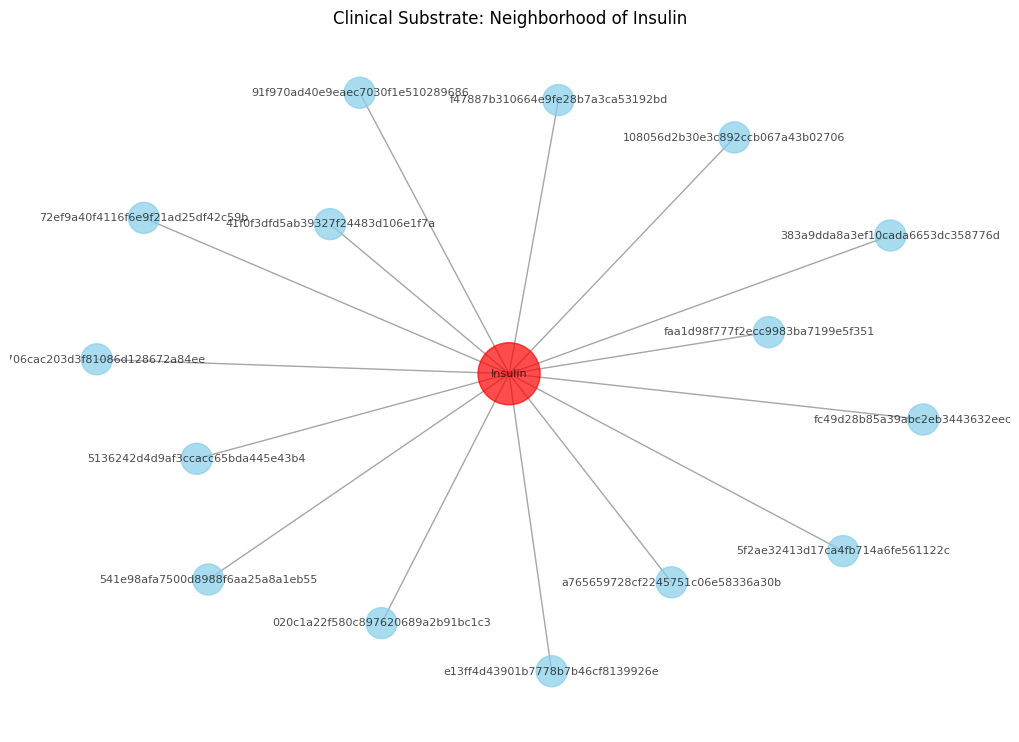

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_substrate_sample(entity_name="Insulin", limit=15):
    # Query to get a 'Neighborhood' of an entity
    query = """
    MATCH (e:Entity {name: $name})-[r:MENTIONS]-(a:Abstract)
    RETURN e.name AS entity, a.id AS abstract_id
    LIMIT $limit
    """
    
    results = substrate.query(query, {"name": entity_name, "limit": limit})
    
    # Build the NetworkX graph
    G = nx.Graph()
    for record in results:
        G.add_node(record['entity'], color='red', size=2000)
        G.add_node(record['abstract_id'], color='skyblue', size=500)
        G.add_edge(record['entity'], record['abstract_id'])

    # Plotting
    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42)
    
    # Draw nodes based on their type (color-coded)
    colors = [data['color'] for n, data in G.nodes(data=True)]
    nx.draw(G, pos, with_labels=True, node_color=colors, 
            node_size=[data['size'] for n, data in G.nodes(data=True)],
            font_size=8, edge_color='gray', alpha=0.7)
    
    plt.title(f"Clinical Substrate: Neighborhood of {entity_name}")
    plt.show()

# Visualize the 'Insulin' hub to prove the substrate is connected
visualize_substrate_sample("Insulin")